# Bike and Pedestrian Traffic

## Set Up

### Import Libraries

In [3]:
import warnings
import os
import sys
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import zipfile

import pprint
from IPython.display import display
import datetime
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf , plot_accf_grid
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from tqdm import tqdm
from joblib import Parallel, delayed
import warnings

from scipy.interpolate import UnivariateSpline

### Import Data

In [6]:
path = os.getcwd()
# path_to_zip = r'C:\Users\conno\ISyE6402Main\Time-Series-Analysis-Project\data\Bike Usage.zip'
path_to_zip = path+'\\Bike Usage.zip'
# 1. Open the zip archive
with zipfile.ZipFile(path_to_zip, 'r') as z:
    # 2. Open the specific CSV file inside the zip
    with z.open('burke-gilman-trail-north-of-ne-70th-st-bike-and-ped-counter.csv') as f:
        # 3. Read it into pandas
        data = pd.read_csv(f)

In [7]:
df = pd.DataFrame(data)

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace = True)


In [5]:
print('NA in 2014')
print(df.loc['2014-1-1':'2015-1-1'].isna().sum())
print()

print('NA in 2015')
print(df.loc['2015-1-1':'2016-1-1'].isna().sum())
print()

print('NA in 2016')
print(df.loc['2016-1-1':'2017-1-1'].isna().sum())
print()

print('NA in 2017')
print(df.loc['2017-1-1':'2018-1-1'].isna().sum())
print()

print('NA in 2018')
print(df.loc['2018-1-1':'2019-1-1'].isna().sum())
print()

print('NA in 2019')
print(df.loc['2019-1-1':'2020-1-1'].isna().sum())
print()

print('NA in 2020')
print(df.loc['2020-1-1':'2021-1-1'].isna().sum())

NA in 2014
BGT North of NE 70th Total    2
Ped South                     2
Ped North                     2
Bike North                    2
Bike South                    2
dtype: int64

NA in 2015
BGT North of NE 70th Total    2
Ped South                     2
Ped North                     2
Bike North                    2
Bike South                    2
dtype: int64

NA in 2016
BGT North of NE 70th Total    1
Ped South                     1
Ped North                     1
Bike North                    1
Bike South                    1
dtype: int64

NA in 2017
BGT North of NE 70th Total    1
Ped South                     1
Ped North                     1
Bike North                    1
Bike South                    1
dtype: int64

NA in 2018
BGT North of NE 70th Total    2329
Ped South                     2329
Ped North                     2329
Bike North                    2329
Bike South                    2329
dtype: int64

NA in 2019
BGT North of NE 70th Total    0
Ped South        

In [6]:
df[df.isna()]

,BGT North of NE 70th Total,Ped South,Ped North,Bike North,Bike South
Date,,,,,
2014-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
2014-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN
2014-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN
2014-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN
2014-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2019-12-31 19:00:00,NaN,NaN,NaN,NaN,NaN
2019-12-31 20:00:00,NaN,NaN,NaN,NaN,NaN
2019-12-31 21:00:00,NaN,NaN,NaN,NaN,NaN


In [7]:
# df = df[:'2018-1-1']
df = df['2019-06-01':'2020-01-01']

In [8]:
# df = df.interpolate(method = 'linear')

In [9]:
# df.isna().sum()

In [10]:
df['Total Ped'] = df['Ped North'] + df['Ped South']
df['Total Bike'] = df['Bike North'] + df['Bike South']


### Examine Data Statistics

In [11]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5136 entries, 2019-06-01 00:00:00 to 2019-12-31 23:00:00
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   BGT North of NE 70th Total  5136 non-null   float64
 1   Ped South                   5136 non-null   float64
 2   Ped North                   5136 non-null   float64
 3   Bike North                  5136 non-null   float64
 4   Bike South                  5136 non-null   float64
 5   Total Ped                   5136 non-null   float64
 6   Total Bike                  5136 non-null   float64
dtypes: float64(7)
memory usage: 321.0 KB


In [12]:
df.describe()

,BGT North of NE 70th Total,Ped South,Ped North,Bike North,Bike South,Total Ped,Total Bike
count,5136.000000,5136.000000,5136.000000,5136.000000,5136.000000,5136.000000,5136.000000
mean,63.063863,8.507399,8.730335,21.625779,24.200350,17.237734,45.826129
std,77.118545,20.754360,15.342830,26.763935,36.114647,32.944599,58.429914
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,2.000000
50%,41.500000,6.000000,6.000000,11.000000,11.000000,13.000000,24.000000
75%,100.000000,14.000000,14.000000,34.000000,34.000000,28.000000,71.000000
max,1764.000000,1324.000000,782.000000,170.000000,961.000000,1752.000000,1039.000000


In [13]:
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (12,12))
#
# ax1.plot('Bike North', data = df)
# ax1.set_title('Bike North')
# ax1.set_ylabel('Count')
# # ax1.set_ylim((0,100))
#
# ax2.plot('Bike South', data = df)
# ax2.set_title('Bike South')
# ax2.set_ylabel('Count')
# # ax2.set_ylim((0,100))
#
# ax3.plot('Total Bike', data = df)
# ax3.set_title('Total Bike')
# ax3.set_ylabel('Count')
# # ax3.set_ylim((0,100))
#
# plt.tight_layout()
# plt.show()

In [14]:
df[df['Total Bike'] == np.max(df['Total Bike'])]

,BGT North of NE 70th Total,Ped South,Ped North,Bike North,Bike South,Total Ped,Total Bike
Date,,,,,,,
2019-08-23 06:00:00,1085.0,38.0,8.0,78.0,961.0,46.0,1039.0


In [15]:
df['last_week'] = df['Bike South'].shift(168)
df['next_week'] = df['Bike South'].shift(-168)

df['imputed'] = (df['last_week'] + df['next_week']) / 2

df.loc['2019-8-23', 'Bike South'] = df.loc['2019-8-23', 'imputed']


In [16]:
df['Total Ped'] = df['Ped North'] + df['Ped South']
df['Total Bike'] = df['Bike North'] + df['Bike South']

df = df.drop(columns =['last_week','next_week','imputed'])

In [17]:
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (12,12))
#
# ax1.plot('Bike North', data = df)
# ax1.set_title('Bike North')
# ax1.set_ylabel('Count')
# ax1.set_ylim((0,300))
#
# ax2.plot('Bike South', data = df)
# ax2.set_title('Bike South')
# ax2.set_ylabel('Count')
# ax2.set_ylim((0,300))
#
# ax3.plot('Total Bike', data = df)
# ax3.set_title('Total Bike')
# ax3.set_ylabel('Count')
# ax3.set_ylim((0,300))
#
# plt.tight_layout()
# plt.show()

In [18]:
df_train = df.loc[:'2019-12-27'].copy()
df_test = df.loc['2019-12-28'].copy()

## Data Exploration

### Pedestrian

#### All Dates

In [19]:
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (12,12))
#
# ax1.plot('Ped North', data = df_train)
# ax1.set_title('Pedestrian North')
# ax1.set_ylabel('Count')
# # ax1.set_ylim((0,100))
#
# ax2.plot('Ped South', data = df_train)
# ax2.set_title('Pedestrian South')
# ax2.set_ylabel('Count')
# # ax2.set_ylim((0,100))
#
# ax3.plot('Total Ped', data = df_train)
# ax3.set_title('Total Pedestrian')
# ax3.set_ylabel('Count')
# # ax3.set_ylim((0,100))
#
# plt.tight_layout()
# plt.show()

#### 1 Month

In [20]:
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (12,12))
#
# ax1.plot('Ped North', data = df_train)
# ax1.set_title('Pedestrian North')
# ax1.set_ylabel('Count')
# # ax1.set_ylim((0,100))
# ax1.set_xlim(datetime.datetime(2015, 5, 1), datetime.datetime(2015, 6, 1))
#
# ax2.plot('Ped South', data = df_train)
# ax2.set_title('Pedestrian South')
# ax2.set_ylabel('Count')
# # ax2.set_ylim((0,100))
# ax2.set_xlim(datetime.datetime(2015, 5, 1), datetime.datetime(2015, 6, 1))
#
# ax3.plot('Total Ped', data = df_train)
# ax3.set_title('Total Pedestrian')
# ax3.set_ylabel('Count')
# # ax3.set_ylim((0,100))
# ax3.set_xlim(datetime.datetime(2015, 5, 1), datetime.datetime(2015, 6, 1))
#
# plt.tight_layout()
# plt.show()

### Bikes

#### All Dates

In [21]:
# fig, ax = plt.subplots(figsize=(12, 4))
#
# plt.plot('Bike North', data=df_train)
# plt.title('Bike North')
# plt.ylabel('Count')
# plt.xlabel('Date')
#
# plt.grid()
# plt.show()

In [22]:
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))
#
# ax1.plot('Bike North', data=df_train)
# ax1.set_title('Bike North')
# ax1.set_ylabel('Count')
#
# ax2.plot('Bike South', data=df_train)
# ax2.set_title('Bike South')
# ax2.set_ylabel('Count')
#
# ax3.plot('Total Bike', data=df_train)
# ax3.set_title('Total Bikes')
# ax3.set_ylabel('Count')
#
# plt.tight_layout()
# plt.show()

#### One Month

In [23]:
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))
#
# ax1.plot('Bike North', data=df_train)
# ax1.set_title('Bike North')
# ax1.set_ylabel('Count')
# ax1.set_ylim((0, 400))
# ax1.set_xlim(datetime.datetime(2015, 5, 1), datetime.datetime(2015, 6, 1))
#
# ax2.plot('Bike South', data=df_train)
# ax2.set_title('Bike South')
# ax2.set_ylabel('Count')
# ax2.set_ylim((0, 400))
# ax2.set_xlim(datetime.datetime(2015, 5, 1), datetime.datetime(2015, 6, 1))
#
# ax3.plot('Total Bike', data=df_train)
# ax3.set_title('Total Bikes')
# ax3.set_ylabel('Count')
# ax3.set_ylim((0, 400))
# ax3.set_xlim(datetime.datetime(2015, 5, 1), datetime.datetime(2015, 6, 1))
#
# plt.tight_layout()
# plt.show()

#### Dedicated Analysis: Bike North

In [24]:
df_train_orig = df_train.copy()
df_train = np.sqrt(df_train+3/8).copy()

##### Daily

In [25]:
# fig, (ax1,ax2) = plt.subplots(1 , 2, figsize=(12, 4))
# plot_acf(df_train['Bike North'], lags = 24*14, ax = ax1, title = 'ACF of Bike North')
# plot_pacf(df_train['Bike North'], lags = 24*14, ax = ax2, title = 'PACF of Bike North')
# plt.tight_layout()
# plt.show()

 ##### Weekly

In [26]:
daily_df_train = df_train.resample('D').sum()

In [27]:
# fig, (ax1,ax2) = plt.subplots(2 , 1, figsize=(12, 6))
# plot_acf(daily_df_train['Bike North'], lags = 21, ax = ax1)
# plot_pacf(daily_df_train['Bike North'], lags = 21, ax = ax2)
# plt.tight_layout()
# plt.show()

In [28]:
time_pts = np.arange(len(df_train['Bike North']))
time_norm = (time_pts - time_pts.min()) / time_pts.max()
spline_bike_north = UnivariateSpline(time_norm, df_train['Bike North'], s=len(df_train['Bike North'])*10)
spline_fit_bike_north = spline_bike_north(time_norm)
df_train['bike_north_fit_gam'] = spline_fit_bike_north
df_train['bike_north_gam_resid'] = df_train['Bike North'] - df_train['bike_north_fit_gam']

In [29]:
# fig, ax = plt.subplots(figsize = (12,4))
# plt.plot(df_train.index, df_train['Bike North'])
# plt.plot(df_train.index, df_train['bike_north_fit_gam'])
# plt.xlabel('Date')
# plt.tight_layout()
# plt.show()

In [30]:
# plt.figure(1,(12,4))
# plt.plot(df_train.index, df_train['bike_north_gam_resid'])
# plt.xlabel('Date')
# plt.tight_layout()
# plt.show()

In [31]:
week_hour = df_train.index.dayofweek*24 + df_train.index.hour

df_train['cos1'] = np.cos(2 * np.pi * (df_train.index.hour) / 12)
df_train['sin1'] = np.sin(2 * np.pi * (df_train.index.hour) / 12)
df_train['cos2'] = np.cos(2 * np.pi * (df_train.index.hour) / 24)
df_train['sin2'] = np.sin(2 * np.pi * (df_train.index.hour) / 24)
df_train['cos3'] = np.cos(2 * np.pi * (week_hour) / 168)
df_train['sin3'] = np.sin(2 * np.pi * (week_hour) / 168)

# Frequency = 2
harmonic_gam_bike_north = smf.ols(formula='bike_north_gam_resid ~ cos1 + sin1 + cos2 + sin2 + cos3 + sin3', data=df_train).fit()
print(harmonic_gam_bike_north.summary())

df_train['bike_north_harmonic_gam_resid'] = harmonic_gam_bike_north.resid

                             OLS Regression Results                             
Dep. Variable:     bike_north_gam_resid   R-squared:                       0.644
Model:                              OLS   Adj. R-squared:                  0.644
Method:                   Least Squares   F-statistic:                     1518.
Date:                  Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                          17:04:12   Log-Likelihood:                -9502.5
No. Observations:                  5040   AIC:                         1.902e+04
Df Residuals:                      5033   BIC:                         1.906e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.223e-13      0.022

In [32]:
# fig, (ax1,ax2,ax3) = plt.subplots(3 , 1,  figsize=(12, 8))
# ax1.plot(df_train['bike_north_harmonic_gam_resid'])
# plot_acf(df_train['bike_north_harmonic_gam_resid'], lags = 24*7, ax = ax2, title = 'ACF of Bike North Residuals')
# plot_pacf(df_train['bike_north_harmonic_gam_resid'], lags = 24*7, ax = ax3, title = 'PACF of Bike North Residuals')
# plt.tight_layout()
# plt.show()



In [33]:
boxTest = acorr_ljungbox(df_train['bike_north_harmonic_gam_resid'], lags=[168])
print(f"Ljung-Box: Test statistic = {boxTest.iloc[0]['lb_stat']:.4f}; p-value = {boxTest.iloc[0]['lb_pvalue']:.4f}")

adfTest = adfuller(df_train['bike_north_harmonic_gam_resid'], autolag='AIC')
print(f"ADF: Test statistic = {adfTest[0]:.4f}; p-value = {adfTest[1]:.4f}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpssTest = kpss(df_train['bike_north_harmonic_gam_resid'], regression='c', nlags='auto')
print(f"KPSS: Test statistic = {kpssTest[0]:.4f}; p-value = {kpssTest[1]:.4f}")


Ljung-Box: Test statistic = 16825.8045; p-value = 0.0000
ADF: Test statistic = -10.0816; p-value = 0.0000
KPSS: Test statistic = 0.1120; p-value = 0.1000


In [34]:
# max_ar=list(range(0,2+1))
# max_ma=list(range(0,3+1))
# max_sar = list(range(0,1+1))
# max_sma = list(range(0,1+1))
# shape = (len(max_ar), len(max_ma), len(max_sar), len(max_sma))
#
# aic_matrix = np.full(shape, np.inf)
# aicc_matrix = np.full(shape, np.inf)
# bic_matrix = np.full(shape, np.inf)
#
# total = shape[0] * shape[1] * shape[2] * shape[3]
# progress = tqdm(total=total, desc="ARIMA Grid Search")
#
# for p in max_ar:
#     for q in max_ma:
#         for P in max_sar:
#             for Q in max_sma:
#                 try:
#                     with warnings.catch_warnings():
#                         warnings.simplefilter("ignore")
#                         fit_result = SARIMAX(
#                             df_train['bike_north_harmonic_gam_resid'],
#                             order=(p, 0, q),
#                             seasonal_order = (P,0,Q,24),
#                             enforce_stationarity = True,
#                             enforce_invertibility = True
#                         ).fit()
#
#                     k = len(fit_result.params)
#                     n = len(df_train['bike_north_harmonic_gam_resid'])
#                     aicc = fit_result.aic + (2 * k**2 + 2 * k) / (n - k - 1)
#
#                     aic_matrix[p, q, P, Q] = fit_result.aic
#                     aicc_matrix[p, q, P, Q] = aicc
#                     bic_matrix[p, q, P, Q] = fit_result.bic
#
#                 except Exception:
#
#                     pass
#
#                 progress.update(1)
#
# progress.close()
# min_idx = np.unravel_index(np.argmin(aicc_matrix), aicc_matrix.shape)
#
# p_best = min_idx[0]
# q_best = min_idx[1]
# P_best = min_idx[2]
# Q_best = min_idx[3]
# best_value = aicc_matrix[min_idx]
#
# print(p_best,
# Q_best ,
# P_best,
# Q_best,
# best_value)

In [35]:
# plt.plot(np.sort(aicc_matrix.flatten())[::-1])

In [36]:
sarima_bike_north = SARIMAX(
                            df_train['bike_north_harmonic_gam_resid'],
                            order=(2, 0, 1),
                            seasonal_order = (1,0,1,24),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

df_train['bike_north_harmonic_gam_sarima_resid'] = sarima_bike_north.resid

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [37]:
# fig, (ax1,ax2,ax3) = plt.subplots(3 , 1,  figsize=(12, 8))
# ax1.plot(df_train['bike_north_harmonic_gam_sarima_resid'])
# plot_acf(df_train['bike_north_harmonic_gam_sarima_resid'], lags = 24*7, ax = ax2, title = 'ACF of Bike North Residuals')
# plot_pacf(df_train['bike_north_harmonic_gam_sarima_resid'], lags = 24*7, ax = ax3, title = 'PACF of Bike North Residuals')
# plt.tight_layout()
# plt.show()

In [38]:
boxTest2 = acorr_ljungbox(df_train['bike_north_harmonic_gam_sarima_resid'], lags=[168], model_df = 5)
print(f"Ljung-Box: Test statistic = {boxTest2.iloc[0]['lb_stat']:.4f}; p-value = {boxTest2.iloc[0]['lb_pvalue']:.4f}")

Ljung-Box: Test statistic = 1442.9864; p-value = 0.0000


In [39]:
# fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(12, 8))
# ax1.plot(df_train['bike_north_harmonic_gam_sarima_resid'])
# plot_acf(df_train['bike_north_harmonic_gam_sarima_resid']**2, lags = 24*7, ax = ax2, title = 'ACF of Bike North Squared Residuals')
# plot_pacf(df_train['bike_north_harmonic_gam_sarima_resid']**2, lags = 24*7, ax = ax3, title = 'PACF of Bike North Squared Residuals')
# plt.tight_layout()
# plt.show()

In [40]:
test_time_pts = np.arange(len(df_train['Bike North']), len(df_train['Bike North']) + len(df_test['Bike North']))

test_time_norm = (test_time_pts - time_pts.min()) / time_pts.max()

pred_spline_bike_north = spline_bike_north(test_time_norm)

In [41]:
test_week_hour = (df_test['Bike North'].index.dayofweek * 24) + df_test['Bike North'].index.hour

df_test['cos1'] = np.cos(2 * np.pi * df_test['Bike North'].index.hour / 12)
df_test['sin1'] = np.sin(2 * np.pi * df_test['Bike North'].index.hour / 12)
df_test['cos2'] = np.cos(2 * np.pi * df_test['Bike North'].index.hour / 24)
df_test['sin2'] = np.sin(2 * np.pi * df_test['Bike North'].index.hour / 24)
df_test['cos3'] = np.cos(2 * np.pi * test_week_hour / 168)
df_test['sin3'] = np.sin(2 * np.pi * test_week_hour / 168)

pred_harmonic_gam_bike_north = harmonic_gam_bike_north.predict(df_test)

In [42]:
pred_sarima_bike_north = sarima_bike_north.forecast(steps=len(df_test['Bike North']))

final_trans_pred = pred_spline_bike_north + pred_harmonic_gam_bike_north.values + pred_sarima_bike_north.values

df_test['bike_north_final_pred'] = final_trans_pred**2 - 3/8

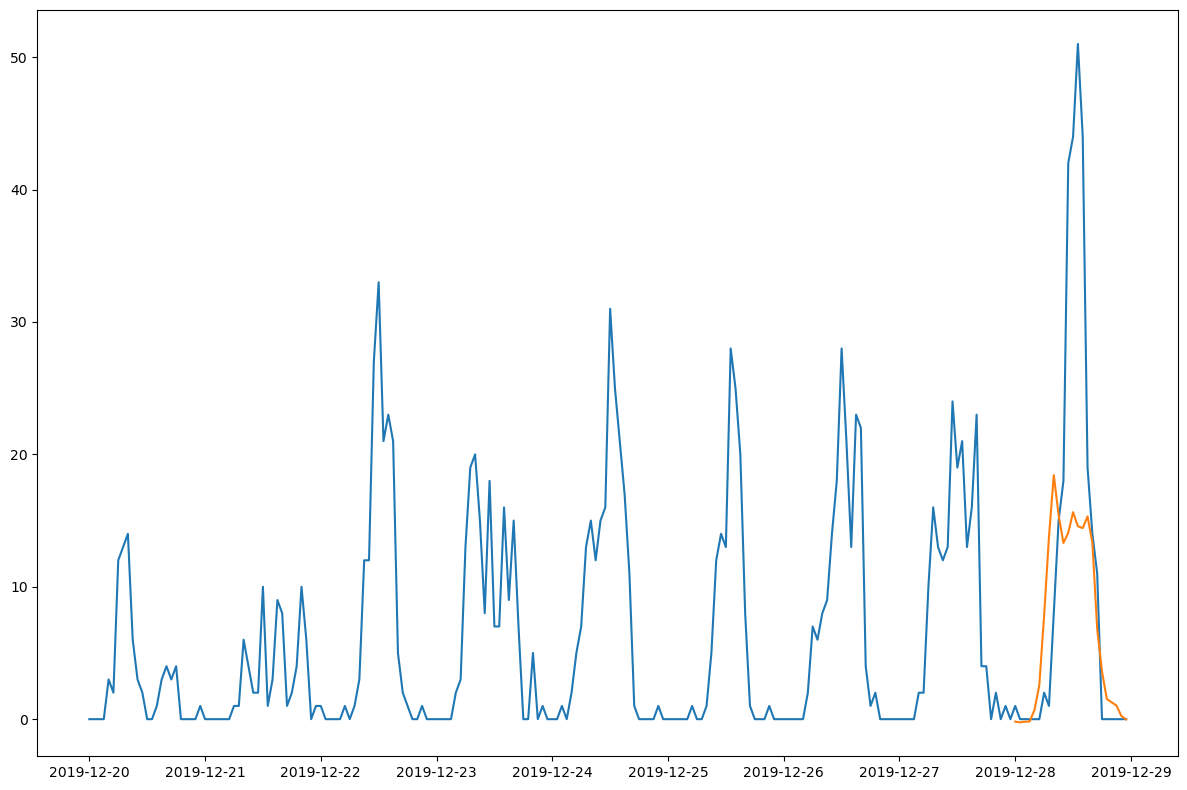

In [43]:
plt.figure(1,(12,8))
plt.plot(df['Bike North'].loc['2019-12-20':'2019-12-28'])
plt.plot(df_test['bike_north_final_pred'])
plt.tight_layout()
plt.show()

In [44]:
df_test['bike_north_final_pred_resid'] = df_test['bike_north_final_pred'] - df_test['Bike North']

final_pred_pm = np.sum(df_test['bike_north_final_pred_resid']**2)/np.sum((df_test['Bike North']-np.mean(df_test['Bike North']))**2)
print(final_pred_pm)

0.642280787294654


In [45]:
# plot_accf_grid(df[['Bike North','Bike South','Ped North','Ped South']],lags=168, fig=plt.figure(figsize=(16, 12)))
# plt.tight_layout()
# plt.show()

In [46]:
# fig, (ax1,ax2) = plt.subplots(1 , 2, figsize=(12, 4))
# plot_acf(df_train['Bike South'], lags = 24*14, ax = ax1, title = 'ACF of Bike South')
# plot_pacf(df_train['Bike South'], lags = 24*14, ax = ax2, title = 'PACF of Bike South')
# plt.tight_layout()
# plt.show()

In [47]:
time_pts = np.arange(len(df_train['Bike South']))
time_norm = (time_pts - time_pts.min()) / time_pts.max()
spline_bike_south = UnivariateSpline(time_norm, df_train['Bike South'], s=len(df_train['Bike South'])*10)
spline_fit_bike_south = spline_bike_south(time_norm)
df_train['bike_south_fit_gam'] = spline_fit_bike_south
df_train['bike_south_gam_resid'] = df_train['Bike South'] - df_train['bike_south_fit_gam']

In [48]:
# fig, ax = plt.subplots(figsize = (12,4))
# plt.plot(df_train.index, df_train['Bike South'])
# plt.plot(df_train.index, df_train['bike_south_fit_gam'])
# plt.xlabel('Date')
# plt.tight_layout()
# plt.show()

In [49]:
# plt.figure(1,(12,4))
# plt.plot(df_train.index, df_train['bike_south_gam_resid'])
# plt.xlabel('Date')
# plt.tight_layout()
# plt.show()

In [50]:
week_hour = df_train.index.dayofweek*24 + df_train.index.hour

df_train['bike_south_cos1'] = np.cos(2 * np.pi * (df_train.index.hour) / 12)
df_train['bike_south_sin1'] = np.sin(2 * np.pi * (df_train.index.hour) / 12)
df_train['bike_south_cos2'] = np.cos(2 * np.pi * (df_train.index.hour) / 24)
df_train['bike_south_sin2'] = np.sin(2 * np.pi * (df_train.index.hour) / 24)
df_train['bike_south_cos3'] = np.cos(2 * np.pi * (week_hour) / 168)
df_train['bike_south_sin3'] = np.sin(2 * np.pi * (week_hour) / 168)

# Frequency = 2
harmonic_gam_bike_south = smf.ols(formula='bike_south_gam_resid ~ bike_south_cos1 + bike_south_sin1 + bike_south_cos2 + bike_south_sin2 + bike_south_cos3 + bike_south_sin3', data=df_train).fit()
print(harmonic_gam_bike_south.summary())

df_train['bike_south_harmonic_gam_resid'] = harmonic_gam_bike_south.resid

                             OLS Regression Results                             
Dep. Variable:     bike_south_gam_resid   R-squared:                       0.688
Model:                              OLS   Adj. R-squared:                  0.688
Method:                   Least Squares   F-statistic:                     1852.
Date:                  Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                          17:04:25   Log-Likelihood:                -9601.1
No. Observations:                  5040   AIC:                         1.922e+04
Df Residuals:                      5033   BIC:                         1.926e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -1.359

In [51]:
# fig, (ax1,ax2,ax3) = plt.subplots(3 , 1,  figsize=(12, 8))
# ax1.plot(df_train['bike_south_harmonic_gam_resid'])
# plot_acf(df_train['bike_south_harmonic_gam_resid'], lags = 24*7, ax = ax2, title = 'ACF of Bike South Residuals')
# plot_pacf(df_train['bike_south_harmonic_gam_resid'], lags = 24*7, ax = ax3, title = 'PACF of Bike South Residuals')
# plt.tight_layout()
# plt.show()

In [52]:
boxTest = acorr_ljungbox(df_train['bike_south_harmonic_gam_resid'], lags=[168])
print(f"Ljung-Box: Test statistic = {boxTest.iloc[0]['lb_stat']:.4f}; p-value = {boxTest.iloc[0]['lb_pvalue']:.4f}")

adfTest = adfuller(df_train['bike_south_harmonic_gam_resid'], autolag='AIC')
print(f"ADF: Test statistic = {adfTest[0]:.4f}; p-value = {adfTest[1]:.4f}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpssTest = kpss(df_train['bike_south_harmonic_gam_resid'], regression='c', nlags='auto')
print(f"KPSS: Test statistic = {kpssTest[0]:.4f}; p-value = {kpssTest[1]:.4f}")

Ljung-Box: Test statistic = 19422.7891; p-value = 0.0000
ADF: Test statistic = -10.3673; p-value = 0.0000
KPSS: Test statistic = 0.0983; p-value = 0.1000


In [53]:
# max_ar=list(range(0,2+1))
# max_ma=list(range(0,3+1))
# max_sar = list(range(0,1+1))
# max_sma = list(range(0,1+1))
# shape = (len(max_ar), len(max_ma), len(max_sar), len(max_sma))
#
# aic_matrix = np.full(shape, np.inf)
# aicc_matrix = np.full(shape, np.inf)
# bic_matrix = np.full(shape, np.inf)
#
# total = shape[0] * shape[1] * shape[2] * shape[3]
# progress = tqdm(total=total, desc="ARIMA Grid Search")
#
# for p in max_ar:
#     for q in max_ma:
#         for P in max_sar:
#             for Q in max_sma:
#                 try:
#                     with warnings.catch_warnings():
#                         warnings.simplefilter("ignore")
#                         fit_result = SARIMAX(
#                             df_train['bike_south_harmonic_gam_resid'],
#                             order=(p, 0, q),
#                             seasonal_order = (P,0,Q,24),
#                             enforce_stationarity = True,
#                             enforce_invertibility = True
#                         ).fit()
#
#                     k = len(fit_result.params)
#                     n = len(df_train['bike_south_harmonic_gam_resid'])
#                     aicc = fit_result.aic + (2 * k**2 + 2 * k) / (n - k - 1)
#
#                     aic_matrix[p, q, P, Q] = fit_result.aic
#                     aicc_matrix[p, q, P, Q] = aicc
#                     bic_matrix[p, q, P, Q] = fit_result.bic
#
#                 except Exception:
#
#                     pass
#
#                 progress.update(1)
#
# progress.close()
# min_idx = np.unravel_index(np.argmin(aicc_matrix), aicc_matrix.shape)
#
# p_best = min_idx[0]
# q_best = min_idx[1]
# P_best = min_idx[2]
# Q_best = min_idx[3]
# best_value = aicc_matrix[min_idx]
#
# print(p_best,
# Q_best ,
# P_best,
# Q_best,
# best_value)

In [54]:
# plt.plot(np.sort(aicc_matrix.flatten())[::-1])

In [55]:
sarima_bike_south = SARIMAX(
                            df_train['bike_south_harmonic_gam_resid'],
                            order=(2, 0, 1),
                            seasonal_order = (1,0,1,24),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

df_train['bike_south_harmonic_gam_sarima_resid'] = sarima_bike_south.resid

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


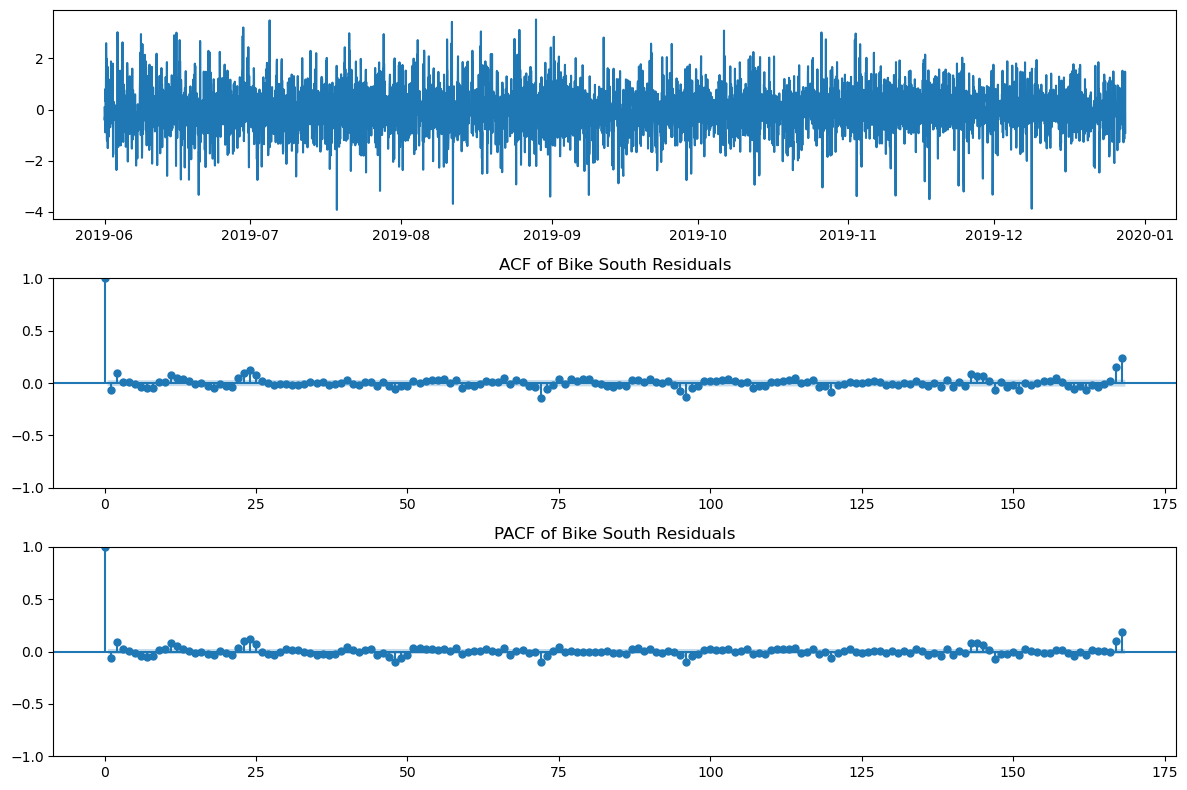

In [56]:
fig, (ax1,ax2,ax3) = plt.subplots(3 , 1,  figsize=(12, 8))
ax1.plot(df_train['bike_south_harmonic_gam_sarima_resid'])
plot_acf(df_train['bike_south_harmonic_gam_sarima_resid'], lags = 24*7, ax = ax2, title = 'ACF of Bike South Residuals')
plot_pacf(df_train['bike_south_harmonic_gam_sarima_resid'], lags = 24*7, ax = ax3, title = 'PACF of Bike South Residuals')
plt.tight_layout()
plt.show()

In [57]:
var_data = pd.DataFrame({'Bike North': df_train['bike_north_harmonic_gam_sarima_resid'],'Bike South': df_train['bike_south_harmonic_gam_sarima_resid']})

var_model = VAR(var_data)
varSelect = var_model.select_order(maxlags=50, trend='c')

print(varSelect.summary())

var_model = VAR(var_data).fit(maxlags=15, trend='c')

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -0.5854     -0.5828      0.5569     -0.5845
1      -0.7412     -0.7333      0.4766     -0.7384
2      -0.7932     -0.7801      0.4524     -0.7886
3      -0.8093     -0.7910      0.4452     -0.8029
4      -0.8249     -0.8014      0.4383     -0.8166
5      -0.8392     -0.8104      0.4321     -0.8291
6      -0.8490     -0.8151      0.4278     -0.8371
7      -0.8640     -0.8248      0.4215     -0.8503
8      -0.8700     -0.8257      0.4189     -0.8545
9      -0.8824     -0.8328      0.4138     -0.8650
10     -0.9194     -0.8645      0.3988     -0.9002
11     -0.9650     -0.9049      0.3810     -0.9439
12     -0.9826     -0.9173      0.3744     -0.9597
13     -0.9979     -0.9274      0.3686     -0.9732
14      -1.018     -0.9421      0.3614     -0.9913
15      -1.036    -0.9549*      0.3549      -1.007
16      -1.039     -0.9529     

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


ARCH Test for Conditional Variance Assumption
(Lagrange Multiplier test p-values)
 Bike North: 4.868099182497988e-28, Bike South: 3.939107843325712e-24

Normality Test for Normality Assumption
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         312.2          9.488   0.000  4
----------------------------------------

Serial Correlation Test
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 16 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         49.19          9.488   0.000  4
----------------------------------------

Unstable Root Count: 0


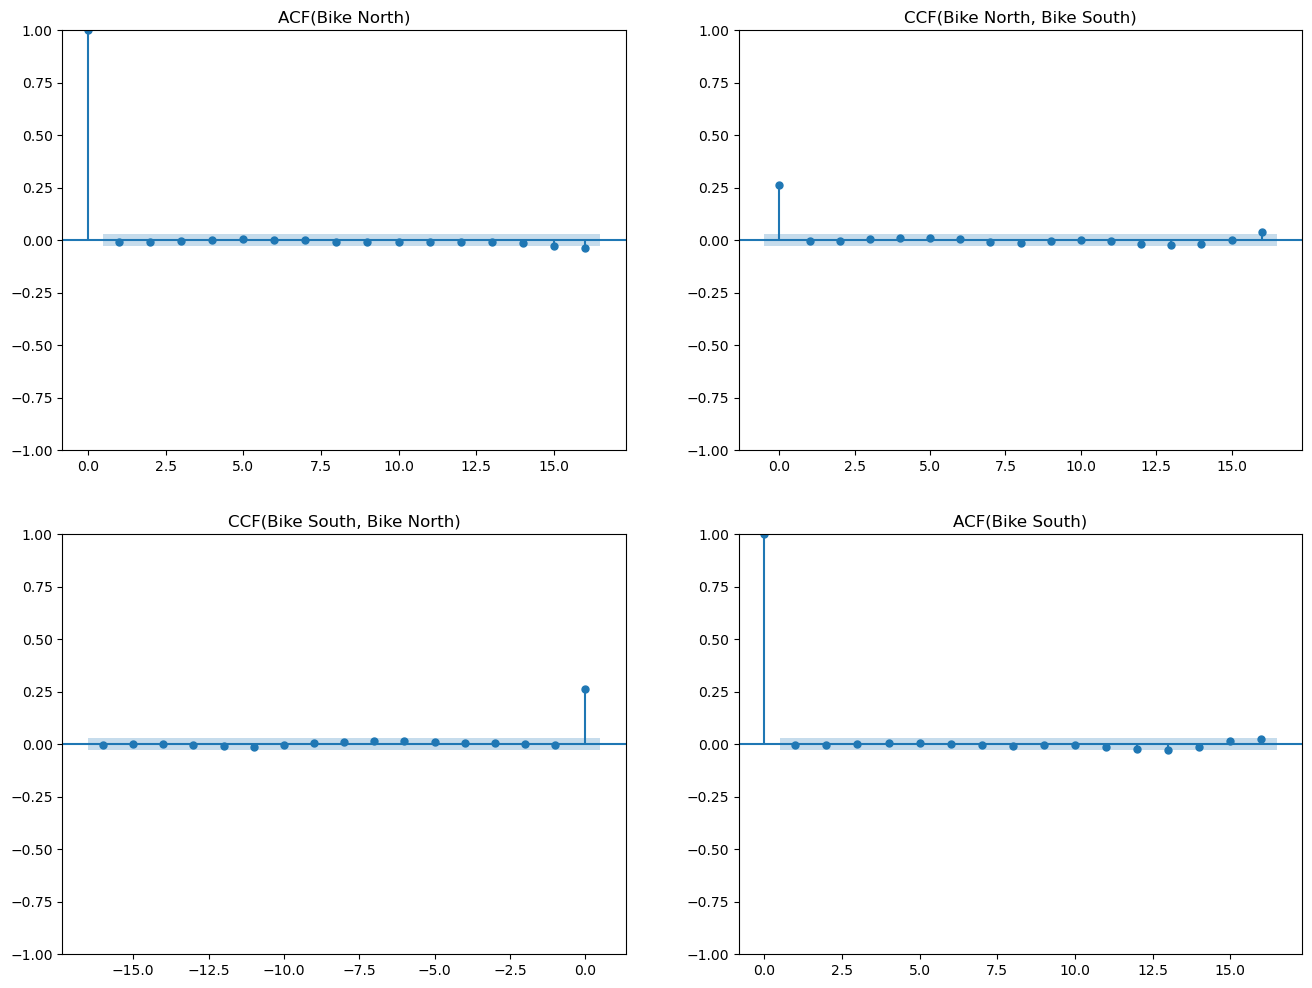

In [58]:
resid_var = var_model.resid


print("ARCH Test for Conditional Variance Assumption")
bike_north, bike_south = het_arch(resid_var['Bike North'])[1], het_arch(resid_var['Bike South'])[1]
print(f"(Lagrange Multiplier test p-values)\n Bike North: {bike_north}, Bike South: {bike_south}")

print("\nNormality Test for Normality Assumption")
print(var_model.test_normality().summary())

# Serial Correlation
print("\nSerial Correlation Test")
print(var_model.test_whiteness(nlags=16).summary())
acf = plot_accf_grid(resid_var, lags=16, fig=plt.figure(figsize=(16, 12)))

# Roots (NOTE: these are the inverse root)
print(f"\nUnstable Root Count: {np.sum(np.abs(var_model.roots) < 1)}")

In [ ]:
df_train['bike_north_harmonic_gam_sarima_resid']

In [63]:
var_pred = var_model.forecast(
    y=df_train[['bike_north_harmonic_gam_sarima_resid','bike_south_harmonic_gam_sarima_resid']].iloc[-15:].values, steps=len(df_test['Bike South']))

In [64]:
final_trans_var_pred = pred_spline_bike_north + pred_harmonic_gam_bike_north.values + pred_sarima_bike_north.values + var_pred[:,0]

df_test['bike_north_final_var_pred'] = final_trans_var_pred**2 - 3/8

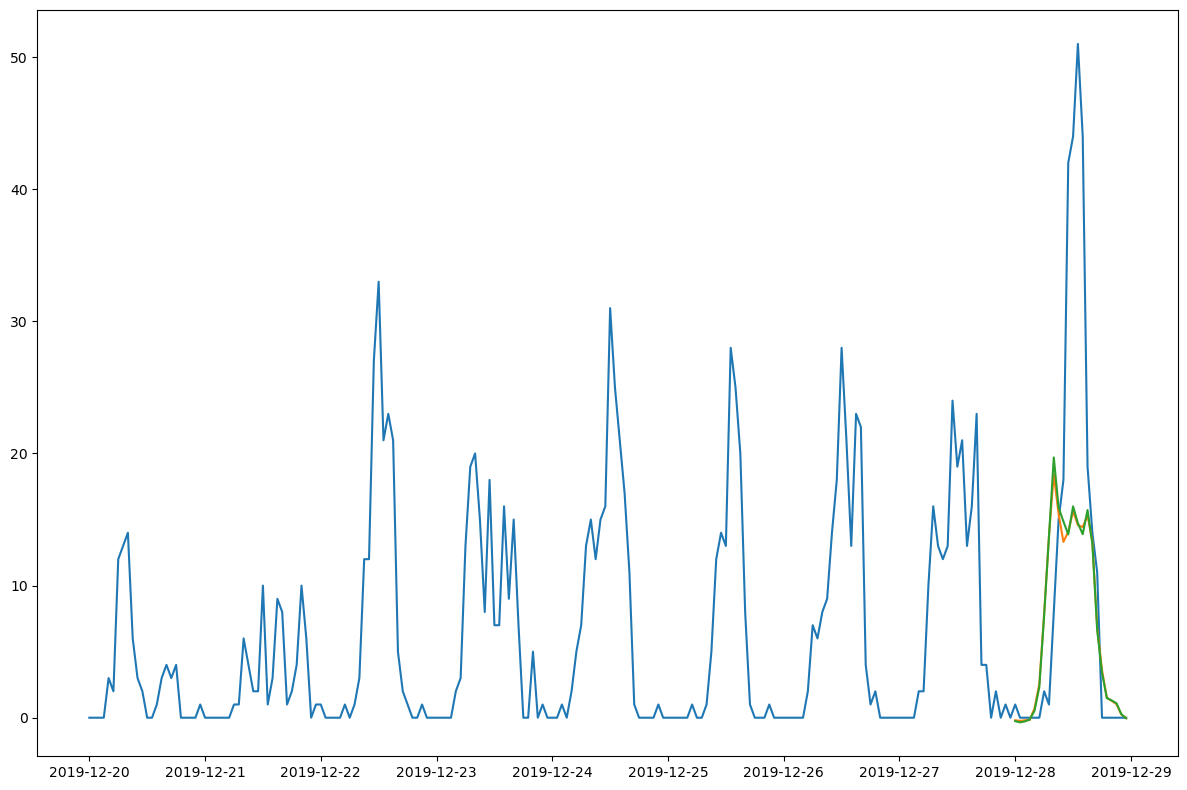

In [65]:
plt.figure(1,(12,8))
plt.plot(df['Bike North'].loc['2019-12-20':'2019-12-28'])
plt.plot(df_test['bike_north_final_pred'])
plt.plot(df_test['bike_north_final_var_pred'])
plt.tight_layout()
plt.show()

In [66]:
df_test['bike_north_final_var_pred_resid'] = df_test['bike_north_final_var_pred'] - df_test['Bike North']

final_var_pred_pm = np.sum(df_test['bike_north_final_var_pred_resid']**2)/np.sum((df_test['Bike North']-np.mean(df_test['Bike North']))**2)
print(final_pred_pm)
print(final_var_pred_pm)

0.642280787294654
0.6456174767740516
